# ESG Data Analysis & Stock Performance

**Based on Lecture 5: Data Preprocessing & Events**

This notebook implements:
- Loading ESG data (Refinitiv/LSEG fields: TR.TRESGScore, TR.TRESGCControversiesScore, TR.EnvironmentPillarScore, etc.)
- **Preprocessing**: missing data, outliers, normalization (per lecture best practices)
- **Time series**: alignment with prices, market-relative returns
- Analysis of how ESG scores relate to stock performance for selected companies.

## 1. Conceptual Framework (Economic Logic)

**Two competing hypotheses:**

| **Positive ESG hypothesis** | **ESG cost hypothesis** |
|-----------------------------|--------------------------|
| Higher ESG → better stock performance | Higher ESG → lower short-term returns |
| Lower regulatory risk, better reputation | Higher compliance costs, lower margins |
| Lower cost of capital, attracts institutional investors | Overinvestment in non-core initiatives |
| ESG as **risk-reduction signal** | ESG may **hurt profitability** in the short run |

**Focus: Shopify (SHOP).** This notebook centers on Shopify; other companies (AAPL, MSFT, JPM, JNJ, XOM) are used for comparison. For Shopify, ESG may signal governance strength, but as a high-growth tech name, performance is largely driven by the tech cycle, interest rates, and macro conditions rather than annual ESG changes.

In [80]:
# Install dependencies into the Python kernel that runs this notebook (run this cell once)
# Restart the kernel after this if you see "restart the kernel to use updated packages"
%pip install -q --disable-pip-version-check pandas numpy matplotlib seaborn scipy scikit-learn statsmodels
# Optional: refinitiv-data for LSEG (can take a few minutes)
# %pip install -q refinitiv-data

Note: you may need to restart the kernel to use updated packages.


## 1. Setup & Imports

We use **pandas** for time series, **numpy** for numerical ops, **scikit-learn** for imputation/normalization, and **LSEG Refinitiv** (refinitiv-data) for both ESG and stock prices.

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats

# LSEG Refinitiv Data Library (install: pip install refinitiv-data)
try:
    import refinitiv.data as rd
    HAS_REFINITIV = True
except ImportError:
    HAS_REFINITIV = False

# Sklearn for preprocessing (lecture: KNN imputer, scaling)
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
%matplotlib inline

## 2. Configuration: Companies & ESG Fields

**Key ESG fields (Refinitiv/LSEG):**
- `TR.HasESGCoverage` – whether the company has ESG coverage
- `TR.TRESGScore` – overall ESG score
- `TR.TRESGCControversiesScore` – controversies score
- `TR.EnvironmentPillarScore` – Environment pillar
- We also include Social and Governance pillars for a complete view.

In [82]:
# Focus company: Shopify. Others are for comparison only.
FOCUS_COMPANY = "SHOP"
COMPANIES = ["SHOP", "AAPL", "MSFT", "JPM", "JNJ", "XOM"]  # SHOP first = focus; rest = peers

# LSEG RIC mapping: ticker -> RIC (exchange suffix .O=Nasdaq, .N=NYSE). Shopify = SHOP.N
COMPANY_RICS = {"SHOP": "SHOP.N", "AAPL": "AAPL.O", "MSFT": "MSFT.O", "JPM": "JPM.N", "JNJ": "JNJ.N", "XOM": "XOM.N"}

# Refinitiv ESG field names (TR.*) and short names for display
# TR.HasESGCoverage: use to filter companies with coverage when using real API
ESG_FIELDS = [
    "TR.TRESGScore",           # Overall ESG score
    "TR.TRESGCControversiesScore",
    "TR.EnvironmentPillarScore",
    "TR.SocialPillarScore",
    "TR.GovernancePillarScore",
]
ESG_COLUMN_NAMES = ["ESGScore", "ControversiesScore", "Environment", "Social", "Governance"]

# Date range for analysis
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"

# LSEG/Refinitiv App Key: load from .env (recommended), or env var, or set in next cell
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
LSEG_APP_KEY = os.environ.get("LSEG_APP_KEY", "")

# Market benchmark for relative returns (LSEG RIC: .SPX = S&P 500)
MARKET_BENCHMARK = ".SPX"

**LSEG App Key:** Best: put `LSEG_APP_KEY=your_key` in a `.env` file (see `.env.example`; never commit `.env`). Or set the env var, or set in the next cell.

In [97]:
# Optional: set LSEG App Key here for this session only (prefer .env or env var)
# LSEG_APP_KEY = "your_key_here"

## 3. Load ESG Data

We try **Refinitiv Data Library** first (for real TR.* fields). If not available or not configured, we use **simulated ESG data** so the notebook runs end-to-end. You can replace the simulated loader with your own CSV/API.

In [98]:
def load_esg_refinitiv(companies, start_date, end_date, app_key=None):
    """Load ESG data from LSEG Refinitiv (requires refinitiv-data and app_key)."""
    if not HAS_REFINITIV:
        return None
    key = app_key or LSEG_APP_KEY
    if not key:
        return None
    try:
        rd.open_session(app_key=key)
        fields_str = ";".join(ESG_FIELDS)
        all_data = []
        for ticker in companies:
            ric = COMPANY_RICS.get(ticker, ticker)
            df = rd.get_history(ric, fields_str, start=start_date, end=end_date)
            if df is not None and not df.empty:
                df["Company"] = ticker
                all_data.append(df)
        rd.close_session()
        if not all_data:
            return None
        out = pd.concat(all_data, ignore_index=True)
        out.columns = ["Date"] + ESG_COLUMN_NAMES + ["Company"]
        out["Date"] = pd.to_datetime(out["Date"]).dt.normalize()
        return out
    except Exception as e:
        print(f"LSEG Refinitiv load failed: {e}")
        return None


def load_esg_simulated(companies, start_date, end_date, seed=42):
    """
    Simulated ESG panel: one row per (company, year) with realistic score ranges.
    Use this when Refinitiv is not available; replace with your CSV/API as needed.
    """
    np.random.seed(seed)
    dates = pd.date_range(start=start_date, end=end_date, freq="YS")  # year-start
    rows = []
    for ticker in companies:
        base_esg = np.clip(np.random.normal(55, 15), 0, 100)
        base_env = np.clip(base_esg + np.random.normal(0, 8), 0, 100)
        base_soc = np.clip(base_esg + np.random.normal(0, 8), 0, 100)
        base_gov = np.clip(base_esg + np.random.normal(0, 8), 0, 100)
        base_cont = np.clip(np.random.uniform(20, 80), 0, 100)
        for d in dates:
            rows.append({
                "Date": d,
                "Company": ticker,
                "ESGScore": np.clip(base_esg + np.random.normal(0, 3), 0, 100),
                "ControversiesScore": np.clip(base_cont + np.random.normal(0, 5), 0, 100),
                "Environment": np.clip(base_env + np.random.normal(0, 4), 0, 100),
                "Social": np.clip(base_soc + np.random.normal(0, 4), 0, 100),
                "Governance": np.clip(base_gov + np.random.normal(0, 4), 0, 100),
            })
    df = pd.DataFrame(rows)
    # Introduce some missing values in score columns only (never Company or Date)
    score_cols_sim = [c for c in df.columns if c not in ("Date", "Company")]
    mask = np.random.random((len(df), len(score_cols_sim))) < 0.08
    df.loc[:, score_cols_sim] = df[score_cols_sim].where(~mask, np.nan)
    return df

In [99]:
# Load ESG data: prefer LSEG Refinitiv (when LSEG_APP_KEY is set), fallback to simulated
esg_raw = load_esg_refinitiv(COMPANIES, START_DATE, END_DATE)
if esg_raw is None:
    if HAS_REFINITIV and not LSEG_APP_KEY:
        print("LSEG_APP_KEY not set. Set it in the cell above or: export LSEG_APP_KEY=your_key")
    print("Using simulated ESG data. Set LSEG_APP_KEY for live LSEG data.")
    esg_raw = load_esg_simulated(COMPANIES, START_DATE, END_DATE)
else:
    print("Loaded ESG data from LSEG Refinitiv.")

esg_raw["Date"] = pd.to_datetime(esg_raw["Date"])
print(esg_raw.head(10))
print("\nShape:", esg_raw.shape)
print("\nMissing per column:")
print(esg_raw.isna().sum())

Using simulated ESG data. Set LSEG_APP_KEY for live LSEG data.
        Date Company   ESGScore  ControversiesScore  Environment     Social  \
0 2020-01-01    SHOP  63.287836           34.413695    59.021085  65.531541   
1 2021-01-01    SHOP  59.678464           16.298373    65.146077  70.898001   
2 2022-01-01    SHOP  61.166574           25.649084    58.531223  59.073738   
3 2023-01-01    SHOP  64.243874                 NaN    62.921530  68.121097   
4 2024-01-01    SHOP  60.649951           34.098318    62.508734  65.089982   
5 2020-01-01    AAPL  53.741716           60.795655    40.465798  47.216702   
6 2021-01-01    AAPL  54.789069           60.608178    47.841886  51.325032   
7 2022-01-01    AAPL  50.414137           57.448143    52.532968  53.903919   
8 2023-01-01    AAPL  53.545921           57.825926    45.596791  54.976151   
9 2024-01-01    AAPL  55.367510           55.555249    47.067629  53.854500   

   Governance  
0   72.349430  
1         NaN  
2   72.117051  
3  

## 4. Cleaning (Lecture: drop duplicates, filter invalid values)

- **Drop duplicates**: same company and date (point-in-time: one observation per company-date).
- **Invalid values**: ESG scores should be in [0, 100]; filter or cap nonsensical values.

In [100]:
score_cols = [c for c in ESG_COLUMN_NAMES if c in esg_raw.columns]

# Drop duplicates: keep last per (Company, Date) as in milestoning
esg_clean = esg_raw.drop_duplicates(subset=["Company", "Date"], keep="last").copy()

# Filter invalid values: scores must be in [0, 100]
for col in score_cols:
    if col in esg_clean.columns:
        invalid = (esg_clean[col].notna()) & ((esg_clean[col] < 0) | (esg_clean[col] > 100))
        esg_clean.loc[invalid, col] = np.nan

print("After cleaning - shape:", esg_clean.shape)
print("Missing after invalid filter:")
print(esg_clean[score_cols].isna().sum())

After cleaning - shape: (30, 7)
Missing after invalid filter:
ESGScore              0
ControversiesScore    5
Environment           4
Social                4
Governance            5
dtype: int64


## 5. Handling Missing Data (Lecture: forward fill, interpolation, KNN)

- **Time series (company-level)**: Forward fill is appropriate for ESG scores that update periodically (e.g. annual); then interpolate for smooth series if needed.
- **Cross-sectional**: For a panel, we can use **KNN imputer** (or MICE) to fill remaining gaps using similar companies/dates.

In [101]:
# Drop rows with missing Company or Date (avoids groupby length mismatch)
esg_clean = esg_clean.dropna(subset=["Company", "Date"]).sort_values(["Company", "Date"])

# Forward fill within each company (lecture: "historical stock price with empty weekends" -> forward fill)
filled = esg_clean.groupby("Company", group_keys=False).apply(
    lambda g: g[score_cols].ffill().bfill()
)
esg_clean[score_cols] = filled.values

# Optional: interpolate for smoother series (linear in time)
for company in esg_clean["Company"].unique():
    mask = esg_clean["Company"] == company
    for col in score_cols:
        ser = esg_clean.loc[mask, col]
        esg_clean.loc[mask, col] = ser.interpolate(method="linear", limit_direction="both")

# Any remaining NaNs: KNN imputer (lecture: "data set of financial statements with missing values")
remaining = esg_clean[score_cols].isna().any(axis=1)
if remaining.sum() > 0:
    imputer = KNNImputer(n_neighbors=3, weights="distance")
    esg_clean.loc[remaining, score_cols] = imputer.fit_transform(esg_clean.loc[remaining, score_cols])

print("Missing after imputation:")

print(esg_clean[score_cols].isna().sum())
esg_clean.head(10)

print("SHOP in esg_clean:", "SHOP" in esg_clean["Company"].values)
if "SHOP" in esg_clean["Company"].values:
    print(esg_clean[esg_clean["Company"] == "SHOP"])

Missing after imputation:
ESGScore              0
ControversiesScore    0
Environment           0
Social                0
Governance            0
dtype: int64
SHOP in esg_clean: True
        Date Company   ESGScore  ControversiesScore  Environment     Social  \
0 2020-01-01    SHOP  63.287836           34.413695    59.021085  65.531541   
1 2021-01-01    SHOP  59.678464           16.298373    65.146077  70.898001   
2 2022-01-01    SHOP  61.166574           25.649084    58.531223  59.073738   
3 2023-01-01    SHOP  64.243874           25.649084    62.921530  68.121097   
4 2024-01-01    SHOP  60.649951           34.098318    62.508734  65.089982   

   Governance  
0   72.349430  
1   72.349430  
2   72.117051  
3   72.573208  
4   70.548742  


## 6. Outlier Detection & Treatment (Lecture: Z-score, IQR; winsorize/capping)

- **Detection**: Z-score (e.g. |z| > 3) and IQR (outside 1.5×IQR).
- **Treatment**: Winsorize (cap at percentiles) rather than drop, to keep time series intact.

In [102]:
def detect_outliers_zscore(series, threshold=3):
    """Flag values more than `threshold` standard deviations from mean."""
    z = np.abs(stats.zscore(series.dropna()))
    return series.index[z > threshold] if len(z) else []

def detect_outliers_iqr(series, k=1.5):
    """Flag values outside Q1 - k*IQR or Q3 + k*IQR."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    return series.index[(series < low) | (series > high)]

def winsorize(series, lower=0.01, upper=0.99):
    """Cap values at percentiles (lecture: capping/winsorize)."""
    return series.clip(lower=series.quantile(lower), upper=series.quantile(upper))

ESGScore: 0 IQR-outliers
ControversiesScore: 0 IQR-outliers
Environment: 0 IQR-outliers
Social: 1 IQR-outliers
Governance: 0 IQR-outliers


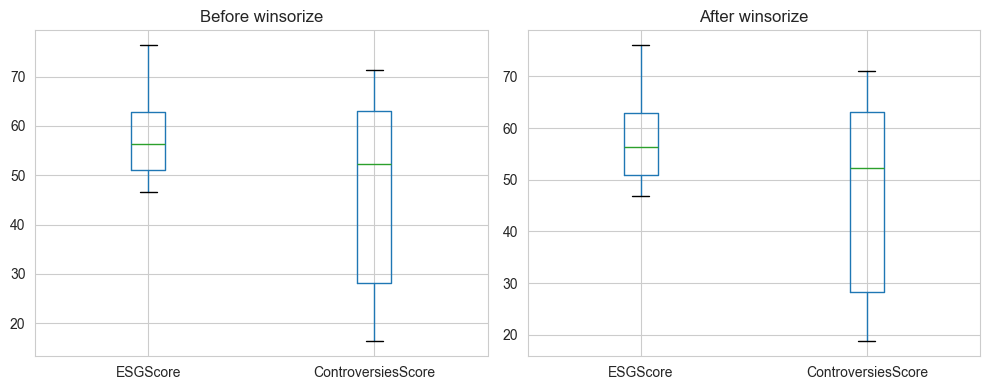

In [103]:
# Report outliers per ESG column (IQR method)
for col in score_cols:
    out_idx = detect_outliers_iqr(esg_clean[col])
    print(f"{col}: {len(out_idx)} IQR-outliers")

# Winsorize at 1% and 99% to limit impact of extremes while keeping series
esg_preprocessed = esg_clean.copy()
for col in score_cols:
    esg_preprocessed[col] = winsorize(esg_preprocessed[col], lower=0.01, upper=0.99)

# Visualize: box plots before/after (one column example)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
esg_clean[["ESGScore", "ControversiesScore"]].boxplot(ax=axes[0])
axes[0].set_title("Before winsorize")
esg_preprocessed[["ESGScore", "ControversiesScore"]].boxplot(ax=axes[1])
axes[1].set_title("After winsorize")
plt.tight_layout()
plt.show()

## 7. Normalization (Lecture: Min-Max, Z-score)

Useful for comparing across pillars or feeding into models. We keep **raw scores** for interpretation and create **normalized** versions for correlation/regression.

In [104]:
# Z-score normalization (per column, cross-sectional)
scaler_z = StandardScaler()
esg_preprocessed[["%s_z" % c for c in score_cols]] = scaler_z.fit_transform(esg_preprocessed[score_cols])

# Min-Max to [0,1] (optional, for ML inputs)
scaler_mm = MinMaxScaler(feature_range=(0, 1))
esg_preprocessed[["%s_norm" % c for c in score_cols]] = scaler_mm.fit_transform(esg_preprocessed[score_cols])

## 8. Stock Returns & Market-Relative Performance (Lecture: event impact)

- Load **stock prices** and **market index** from **LSEG** (same session as ESG).
- Compute **daily returns** and **market-relative returns**: stock return − market return (to isolate company-specific performance).

In [105]:
def load_returns_lseg(companies, start_date, end_date, benchmark_ric, app_key=None):
    """Load daily close prices from LSEG, compute market-relative returns."""
    if not HAS_REFINITIV:
        return None
    key = app_key or LSEG_APP_KEY
    if not key:
        return None
    try:
        rd.open_session(app_key=key)
        try:
            # TR.PriceClose for daily close; use RIC for API, ticker for column names (so SHOP appears)
            close_dfs = []
            for ticker in companies:
                ric = COMPANY_RICS.get(ticker, ticker)
                df = rd.get_history(ric, "TR.PriceClose", start=start_date, end=end_date, interval="daily")
                if df is not None and not df.empty:
                    col = df.columns[0] if len(df.columns) else "Close"
                    close_dfs.append(df[col].rename(ticker))
            # Fetch benchmark (e.g. .SPX) for market-relative returns
            df_mkt = rd.get_history(benchmark_ric, "TR.PriceClose", start=start_date, end=end_date, interval="daily")
            if df_mkt is None or df_mkt.empty:
                return None
            col_mkt = df_mkt.columns[0] if len(df_mkt.columns) else "Close"
            close_dfs.append(df_mkt[col_mkt].rename(benchmark_ric))
            if len(close_dfs) < 2:
                return None
            close = pd.concat(close_dfs, axis=1).ffill().bfill()
            if benchmark_ric not in close.columns:
                return None
            ret = close.pct_change().dropna()
            market_ret = ret[benchmark_ric]
            stock_cols = [c for c in companies if c in ret.columns]
            if not stock_cols:
                return None
            returns_df = ret[stock_cols].sub(market_ret, axis=0).dropna(how="all")
            return returns_df
        finally:
            rd.close_session()
    except Exception as e:
        print(f"LSEG price load failed: {e}")
        return None

# Load returns from LSEG (requires LSEG_APP_KEY)
returns_df = load_returns_lseg(COMPANIES, START_DATE, END_DATE, MARKET_BENCHMARK)
if returns_df is None:
    if HAS_REFINITIV and not LSEG_APP_KEY:
        print("LSEG_APP_KEY not set. Set it above to load prices from LSEG.")
    print("Using placeholder returns (set LSEG_APP_KEY for live LSEG price data).")
else:
    print("Loaded daily returns from LSEG. Market-relative returns (sample):")
    print(returns_df.tail())

Using placeholder returns (set LSEG_APP_KEY for live LSEG price data).


## 9. ESG vs Stock Performance Analysis

- **Align** ESG (e.g. annual) with **period returns**: use ESG as of start of period to avoid look-ahead bias (point-in-time).
- Compute **annual (or period) market-relative returns** and correlate with ESG scores.

In [106]:
# Annual market-relative return per company (sum of daily rel returns ≈ log return proxy)
if returns_df is not None and not returns_df.empty:
    returns_df.index = pd.to_datetime(returns_df.index)
    annual_ret = returns_df.resample("YS").apply(lambda x: (1 + x).prod() - 1)
    annual_ret.index = annual_ret.index.year
    annual_ret = annual_ret.stack().reset_index()
    annual_ret.columns = ["Year", "Company", "AnnRelReturn"]
else:
    # Placeholder when LSEG prices not loaded
    annual_ret = esg_preprocessed.copy()
    annual_ret["Year"] = pd.to_datetime(annual_ret["Date"]).dt.year
    annual_ret["AnnRelReturn"] = np.random.normal(0, 0.1, len(annual_ret))
    annual_ret = annual_ret[["Year", "Company", "AnnRelReturn"]].drop_duplicates()

In [107]:
# Point-in-time: use ESG as of beginning of year for that year's return
esg_preprocessed["Year"] = pd.to_datetime(esg_preprocessed["Date"]).dt.year
# For each (Company, Year) take latest available ESG before/during that year
esg_by_year = esg_preprocessed.sort_values("Date").groupby(["Company", "Year"], as_index=False).last()
# Force all COMPANIES (including SHOP) to appear: fill missing (Company, Year) with NaN
years_in_data = sorted(esg_by_year["Year"].dropna().unique()) if len(esg_by_year) > 0 else list(range(int(START_DATE[:4]), int(END_DATE[:4]) + 1))
full_grid = pd.DataFrame([(c, y) for c in COMPANIES for y in years_in_data], columns=["Company", "Year"])
esg_by_year = full_grid.merge(esg_by_year, on=["Company", "Year"], how="left")
# Left merge from ESG so all companies appear; returns NaN where no price data
merged = esg_by_year[["Company", "Year"] + score_cols].merge(
    annual_ret, on=["Company", "Year"], how="left"
)
print("Merged ESG + returns (point-in-time aligned):")
# Show focus company (Shopify) first, then peers
shop = merged[merged["Company"] == FOCUS_COMPANY]
peers = merged[merged["Company"] != FOCUS_COMPANY]
if len(shop) > 0:
    print(f"\n--- {FOCUS_COMPANY} (Shopify, focus) ---")
    print(shop.to_string())
if len(peers) > 0:
    print(f"\n--- Peers (comparison) ---")
    print(peers.head(10).to_string())
else:
    print(merged.head(12))

Merged ESG + returns (point-in-time aligned):

--- SHOP (Shopify, focus) ---
  Company  Year   ESGScore  ControversiesScore  Environment     Social  Governance  AnnRelReturn
0    SHOP  2020  63.287836           34.413695    59.021085  65.531541   72.349430      0.082542
1    SHOP  2021  59.678464           18.718192    65.146077  70.898001   72.349430      0.081351
2    SHOP  2022  61.166574           25.649084    58.531223  59.073738   72.117051      0.130548
3    SHOP  2023  64.243874           25.649084    62.921530  68.121097   72.508313      0.002100
4    SHOP  2024  60.649951           34.098318    62.508734  65.089982   70.548742      0.068195

--- Peers (comparison) ---
   Company  Year   ESGScore  ControversiesScore  Environment     Social  Governance  AnnRelReturn
5     AAPL  2020  53.741716           60.795655    40.465798  47.216702   51.525511     -0.058936
6     AAPL  2021  54.789069           60.608178    47.841886  51.325032   44.823978      0.084960
7     AAPL  2022  5

Correlation of ESG pillars with annual market-relative return:
Environment           0.143874
ESGScore              0.112250
Governance            0.111768
Social                0.011972
ControversiesScore   -0.337420
Name: AnnRelReturn, dtype: float64


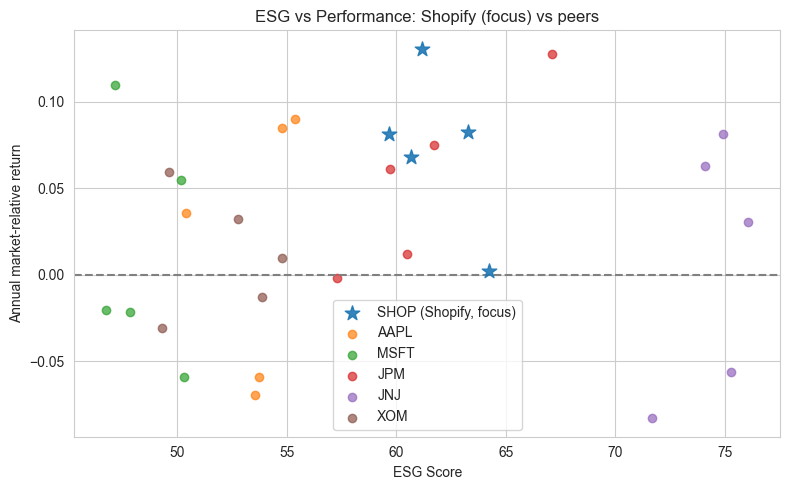


--- SHOP (Shopify) vs peers ---
  Shopify:  mean ESG = 61.81,  mean ann. rel. return = 0.0729
  Peers:    mean ESG = 57.96,  mean ann. rel. return = 0.0205


In [108]:
# Correlation: ESG scores vs annual market-relative return (only rows with returns)
merged_with_ret = merged.dropna(subset=["AnnRelReturn"]) if "AnnRelReturn" in merged.columns else pd.DataFrame()
if "AnnRelReturn" in merged.columns and len(merged_with_ret) > 5:
    corr = merged_with_ret[score_cols + ["AnnRelReturn"]].corr()["AnnRelReturn"].drop("AnnRelReturn")
    print("Correlation of ESG pillars with annual market-relative return:")
    print(corr.sort_values(ascending=False))
    # Scatter: ESG Score vs return
    fig, ax = plt.subplots(figsize=(8, 5))
    # Plot peers first, then Shopify (focus) on top with distinct style
    for company in merged_with_ret["Company"].unique():
        m = merged_with_ret[merged_with_ret["Company"] == company]
        if company == FOCUS_COMPANY:
            ax.scatter(m["ESGScore"], m["AnnRelReturn"], s=120, marker="*", zorder=5, label=f"{company} (Shopify, focus)", alpha=0.9)
        else:
            ax.scatter(m["ESGScore"], m["AnnRelReturn"], label=company, alpha=0.7)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("ESG Score")
    ax.set_ylabel("Annual market-relative return")
    ax.legend()
    ax.set_title("ESG vs Performance: Shopify (focus) vs peers")
    plt.tight_layout()
    plt.show()
    # Shopify vs peers summary
    s = merged_with_ret[merged_with_ret["Company"] == FOCUS_COMPANY]
    p = merged_with_ret[merged_with_ret["Company"] != FOCUS_COMPANY]
    if len(s) > 0 and len(p) > 0:
        print(f"\n--- {FOCUS_COMPANY} (Shopify) vs peers ---")
        print(f"  Shopify:  mean ESG = {s['ESGScore'].mean():.2f},  mean ann. rel. return = {s['AnnRelReturn'].mean():.4f}")
        print(f"  Peers:    mean ESG = {p['ESGScore'].mean():.2f},  mean ann. rel. return = {p['AnnRelReturn'].mean():.4f}")
else:
    print("Not enough data for correlation. Set LSEG_APP_KEY and load LSEG price data for more points.")

## 2. Empirical Strategy: Regression

We test whether **ESG score** is associated with **annual (market-relative) return**:

$$R_t = \alpha + \beta \cdot \text{ESG}_t + \epsilon_t$$

- **β > 0 and significant** → Positive ESG hypothesis (ESG associated with better performance).
- **β < 0 and significant** → ESG cost hypothesis (ESG associated with lower returns).
- **β insignificant** → ESG not a main driver of returns in this sample.

*Note: We use **market-relative return** (excess over benchmark), so market movement is already partialled out. A stronger specification would be raw return with market return as control: $R_t = \alpha + \beta_1 \text{ESG}_t + \beta_2 \text{MarketReturn}_t + \epsilon_t$.*

In [109]:
# Regression: AnnRelReturn = α + β·ESGScore + ε (only rows with valid returns)
df_reg = merged_with_ret.dropna(subset=["ESGScore", "AnnRelReturn"])[["ESGScore", "AnnRelReturn"]]
if len(df_reg) < 5:
    print("Not enough observations for regression. Need ESG and returns for multiple company-years.")
else:
    try:
        import statsmodels.api as sm
        X = sm.add_constant(df_reg["ESGScore"])
        model = sm.OLS(df_reg["AnnRelReturn"], X).fit()
        print(model.summary())
        beta, alpha = model.params["ESGScore"], model.params["const"]
        p_esg = model.pvalues["ESGScore"]
        print("\nInterpretation:")
        if p_esg < 0.05:
            print(f"  β (ESG) = {beta:.4f} (p = {p_esg:.4f}) — significant.")
            print("  → Positive ESG hypothesis" if beta > 0 else "  → ESG cost hypothesis")
        else:
            print(f"  β (ESG) = {beta:.4f} (p = {p_esg:.4f}) — not significant.")
            print("  → ESG is not a significant driver of (excess) returns in this sample.")
    except ImportError:
        from scipy import stats as st
        slope, intercept, r, p, se = st.linregress(df_reg["ESGScore"], df_reg["AnnRelReturn"])
        print(f"AnnRelReturn = {intercept:.4f} + {slope:.4f} * ESGScore")
        print(f"R² = {r**2:.4f}, p-value = {p:.4f}")
        print("→ ESG significant" if p < 0.05 else "→ ESG not significant")

                            OLS Regression Results                            
Dep. Variable:           AnnRelReturn   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                 -0.023
Method:                 Least Squares   F-statistic:                    0.3573
Date:                Tue, 24 Feb 2026   Prob (F-statistic):              0.555
Time:                        01:11:51   Log-Likelihood:                 42.178
No. Observations:                  30   AIC:                            -80.36
Df Residuals:                      28   BIC:                            -77.55
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0154      0.076     -0.204      0.8

## 3. Interpretation (e.g. for Shopify) & Limitations

**Interpretation for Shopify (SHOP):**  
Shopify is high-growth tech, highly volatile (e.g. 2020–2022), sensitive to rates and macro. Its stock performance is likely driven more by **growth expectations and macro conditions** than by annual changes in ESG. A mature conclusion: *While ESG may influence long-term risk perception, Shopify’s performance appears primarily driven by macroeconomic conditions and growth expectations rather than ESG score changes.*

**Limitations (A-level nuance):**
- **Time frequency mismatch:** ESG updates slowly (annual); returns fluctuate daily/monthly — alignment is coarse.
- **Omitted variables:** Beta, sector, size, profitability are not controlled for; ESG effect may be confounded.
- **Endogeneity:** Good performance may allow more ESG investment (reverse causality).
- **Market control:** Using excess return already controls for market; a regression with raw return and market return would separate ESG effect from market movement more explicitly.

## 10. Summary & Best Practices (Lecture 5)

- **Cleaning**: Dropped duplicates (Company, Date), capped invalid score ranges.
- **Missing data**: Forward fill (time series) → linear interpolation → KNN imputer for remainder.
- **Outliers**: IQR detection, winsorization at 1%/99%.
- **Normalization**: Z-score and Min-Max for optional downstream use.
- **Time series**: ESG aligned with returns using **point-in-time** (no look-ahead); **market-relative returns** to isolate stock-specific performance.
- **Storage**: You can persist `esg_preprocessed` to CSV/Parquet/Feather (lecture: common storage formats) for your app.

In [110]:
# Optional: save preprocessed ESG for your app
# esg_preprocessed.to_parquet("esg_preprocessed.parquet", index=False)
# esg_preprocessed.to_csv("esg_preprocessed.csv", index=False)
print("Preprocessed ESG shape:", esg_preprocessed.shape)
print("Columns:", list(esg_preprocessed.columns))

Preprocessed ESG shape: (30, 18)
Columns: ['Date', 'Company', 'ESGScore', 'ControversiesScore', 'Environment', 'Social', 'Governance', 'ESGScore_z', 'ControversiesScore_z', 'Environment_z', 'Social_z', 'Governance_z', 'ESGScore_norm', 'ControversiesScore_norm', 'Environment_norm', 'Social_norm', 'Governance_norm', 'Year']
